Read the xml file

In [22]:
import xml.etree.ElementTree as ET

xml_file = "../data/benchmark_results_multicore.xml" 
tree = ET.parse(xml_file)
root = tree.getroot()
data_from_xml = []

for testcase in root.iter("testcase"):
    props = {}
    for prop in testcase.find("properties").iter("property"):
        name = prop.attrib["name"]
        value = prop.attrib["value"]
        props[name] = value

    entry = {
             "circuit_class": props["circuit_class"],
            "num_qubits": int(props["num_qubits"]),
            "num_blocks": int(props["num_blocks"]),
            "time_sec": float(props["time_sec"]),
            "peak_memory_mb": float(props["peak_memory_bytes"]) / (1024**2),
            "num_threads": int(props["num_threads"])
        }
    data_from_xml.append(entry)


In [21]:
data_from_xml[0]

{'circuit_class': 'QuspinQuantumSensingCircuit',
 'num_qubits': 4,
 'num_blocks': 1,
 'time_sec': 0.7000411208719015,
 'peak_memory_mb': 16.215288162231445,
 'num_threads': 1}

Plot the results for analyzing number of threads

In [23]:
import matplotlib.pyplot as plt

def get_grouped_data(raw_data, class_name, filters):
    """
    Filters raw data by class_name and a dictionary of exact match filters.
    Returns a dictionary grouped by 'num_threads'.
    """
    filtered = [
        d for d in raw_data 
        if d['circuit_class'] == class_name and all(d[k] == v for k, v in filters.items())
    ]
    
    grouped = {}
    for entry in filtered:
        t = entry['num_threads']
        if t not in grouped: grouped[t] = []
        grouped[t].append(entry)
    return grouped

def plot_metric(ax, grouped_data, x_config, y_config, title):
    """
    Sorts and plots data on the given axis.
    x_config: tuple (key_name, label_text)
    y_config: tuple (key_name, label_text)
    """
    x_key, x_label = x_config
    y_key, y_label = y_config
    
    # Sort thread keys for consistent legend order
    for threads in sorted(grouped_data.keys()):
        entries = grouped_data[threads]
        
        # Sort entries by x-axis value to ensure clean line plots (prevents zigzag)
        entries_sorted = sorted(entries, key=lambda e: e[x_key])
        
        x_values = [e[x_key] for e in entries_sorted]
        y_values = [e[y_key] for e in entries_sorted]
        
        ax.plot(x_values, y_values, marker='o', label=f"{threads} threads")
    
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

def generate_grid_plots(data, unique_classes, filters, x_config):
    """
    Generates a 4x2 grid of plots (Time/Memory) for the given classes and filters.
    """
    if not unique_classes:
        print("No classes provided to plot.")
        return

    # Create subplots: Rows = Classes, Cols = 2 (Time, Memory)
    fig, axes = plt.subplots(nrows=len(unique_classes), ncols=2, figsize=(15, 5 * len(unique_classes)))

    # Ensure axes is always 2D array [row][col]
    if len(unique_classes) == 1:
        axes = axes.reshape(1, -1)
        
    # Standard Y-axis configurations
    y_config_time = ("time_sec", "Time (s)")
    y_config_mem = ("peak_memory_mb", "Memory (Megabytes)")

    for i, cclass in enumerate(unique_classes):
        # 1. Get Data
        grouped_data = get_grouped_data(data, cclass, filters)
        
        # Filter description string for titles
        filter_str = ", ".join([f"{k}={v}" for k,v in filters.items()])
        
        # 2. Plot Time (Column 0)
        ax_time = axes[i][0]
        plot_metric(
            ax_time, grouped_data, x_config, y_config_time, 
            title=f"{cclass} - Time ({filter_str})"
        )

        # 3. Plot Memory (Column 1)
        ax_mem = axes[i][1]
        plot_metric(
            ax_mem, grouped_data, x_config, y_config_mem, 
            title=f"{cclass} - Memory ({filter_str})"
        )

    plt.tight_layout()
    plt.show()



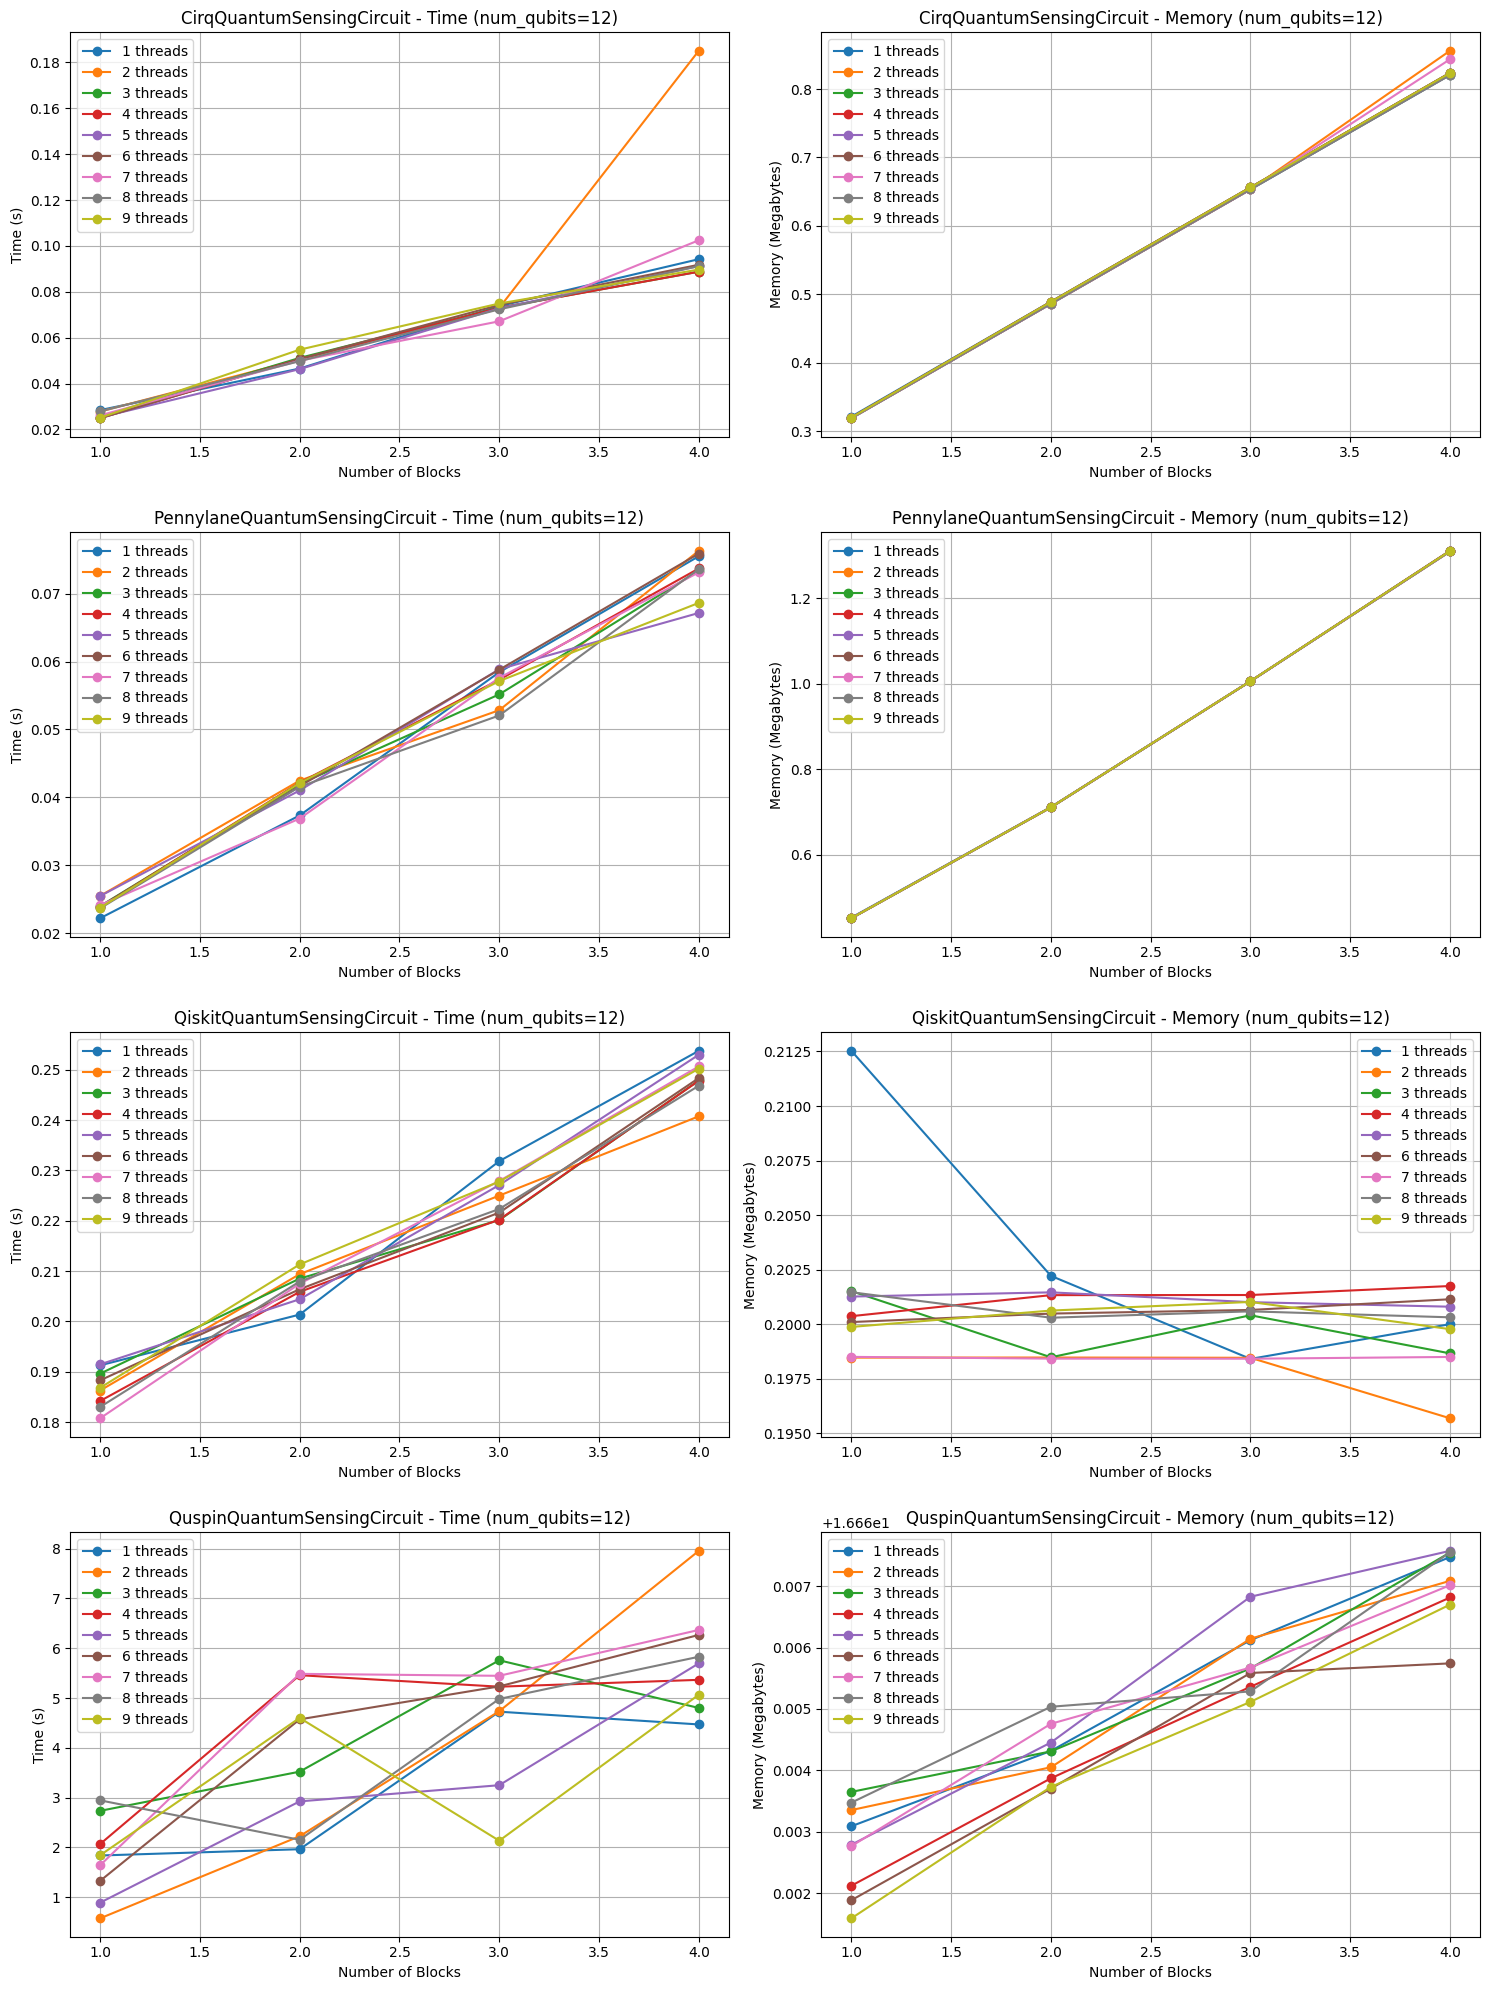

In [24]:
classes = sorted(list(set(d['circuit_class'] for d in data_from_xml)))

generate_grid_plots(
    data=data_from_xml,
    unique_classes=classes,
    filters={"num_qubits": 12}, 
    x_config=("num_blocks", "Number of Blocks")
)


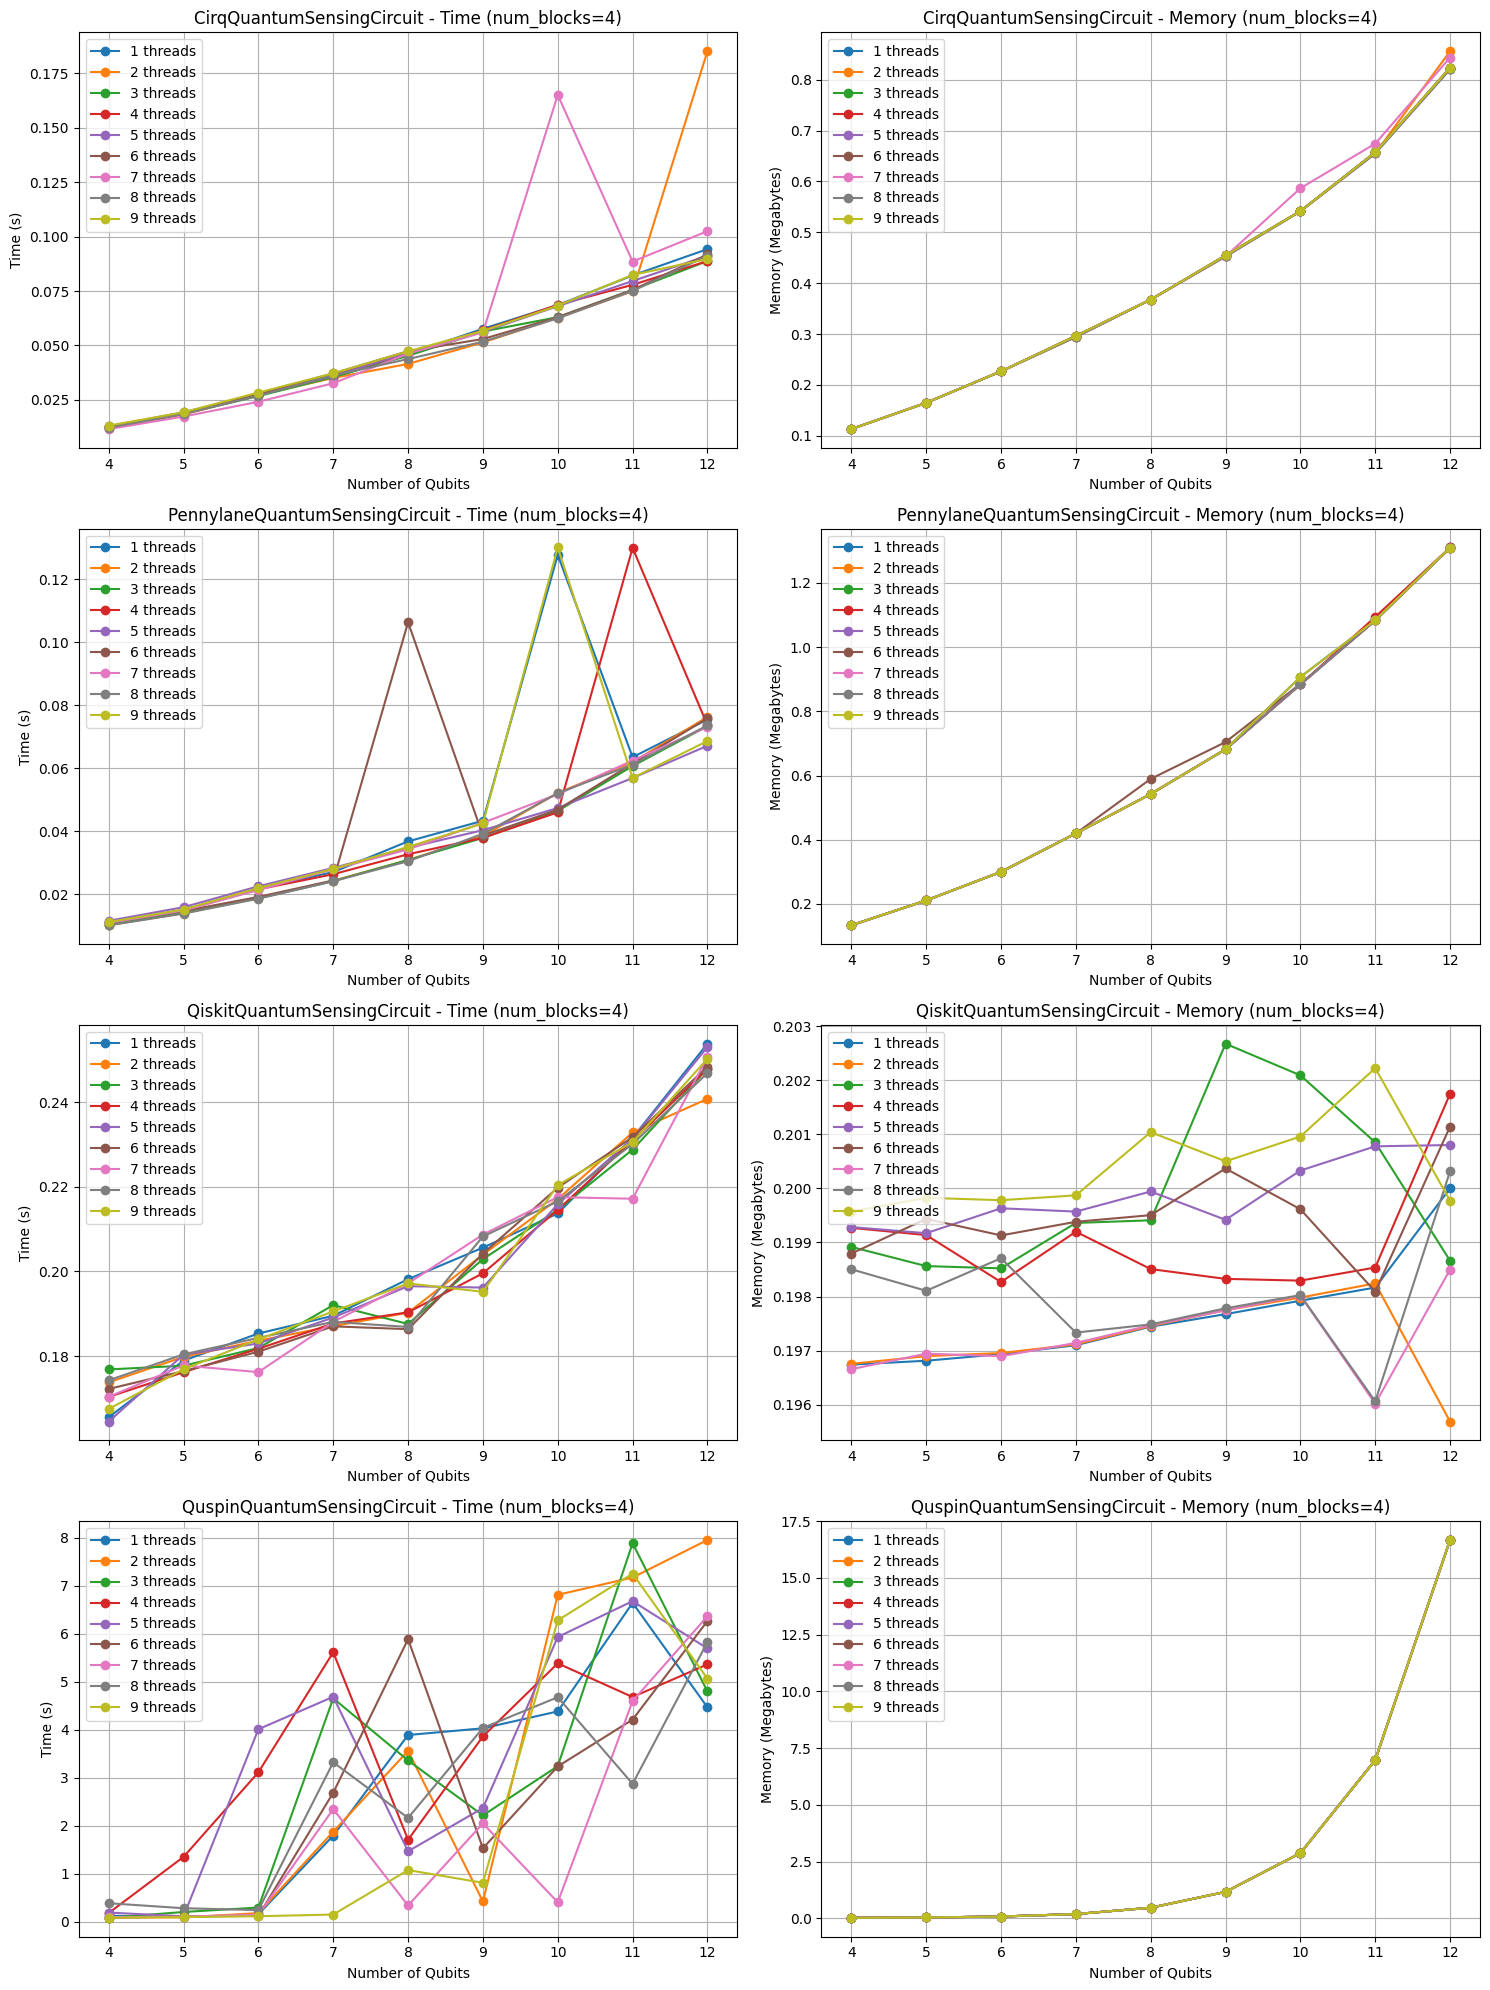

In [25]:
generate_grid_plots(
    data=data_from_xml,
    unique_classes=classes,
    filters={"num_blocks": 4},
    x_config=("num_qubits", "Number of Qubits")
)
